In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **EDA**

In [104]:
df = pd.read_csv('data/train.csv')

In [105]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [106]:
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

Arrival delay in Minutes is the only column with missing data. I'll replace NaN with 0 because I believe that missing data in this column indicates no delay.

I will Unnamed: 0 and id because it is not necessary to have this data.

In [107]:
df.drop(columns=['Unnamed: 0', 'id'], inplace=True)

In [108]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  str    
 1   Customer Type                      103904 non-null  str    
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  str    
 4   Class                              103904 non-null  str    
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    103904 non-null

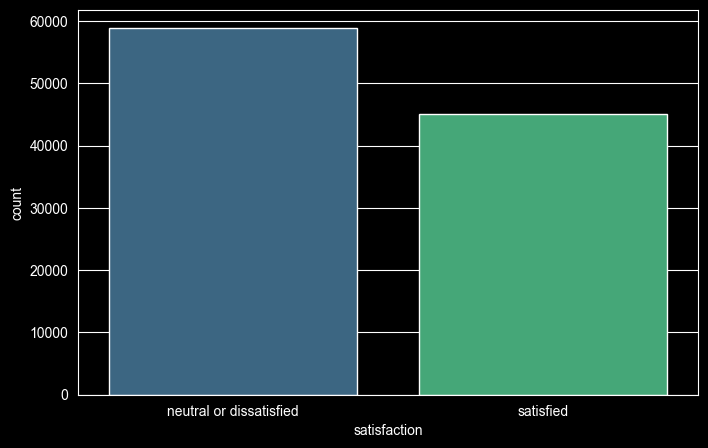

In [110]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='satisfaction', data=df, palette='viridis', hue='satisfaction')
plt.show()

Dataset is only slight imbalance.

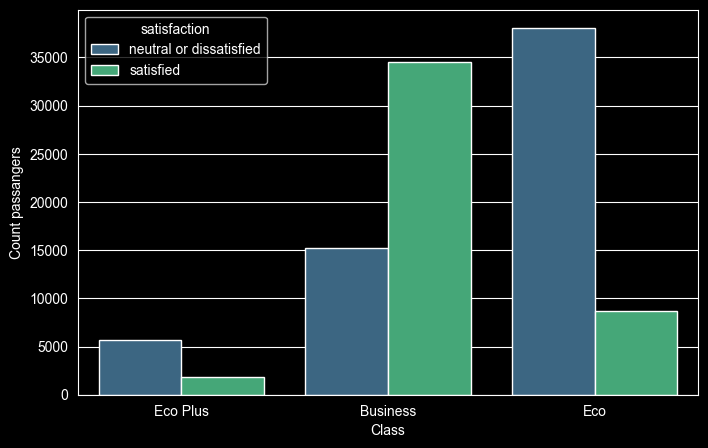

In [111]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Class',
    hue='satisfaction',
    palette='viridis'
)
plt.xlabel('Class')
plt.ylabel('Count passangers')
plt.show()

There is a significant correlation between `Business Class` and higher satisfaction levels. Passengers in `Eco` and `Eco Plus` are predominantly "Neutral or Dissatisfied."

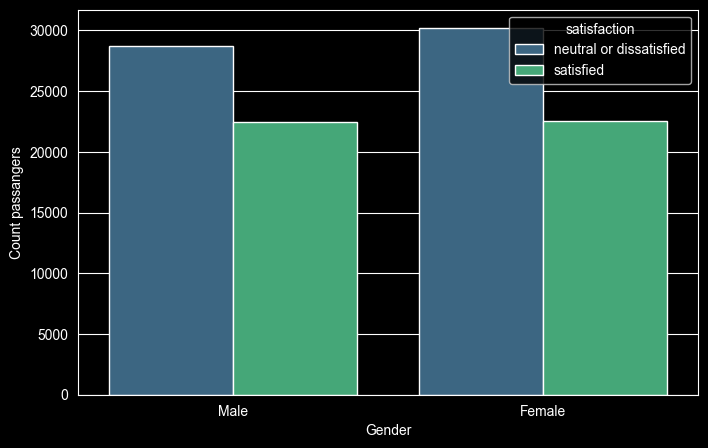

In [112]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Gender',
    hue='satisfaction',
    palette='viridis'
)
plt.xlabel('Gender')
plt.ylabel('Count passangers')
plt.show()

Satisfaction is similar in both gender.

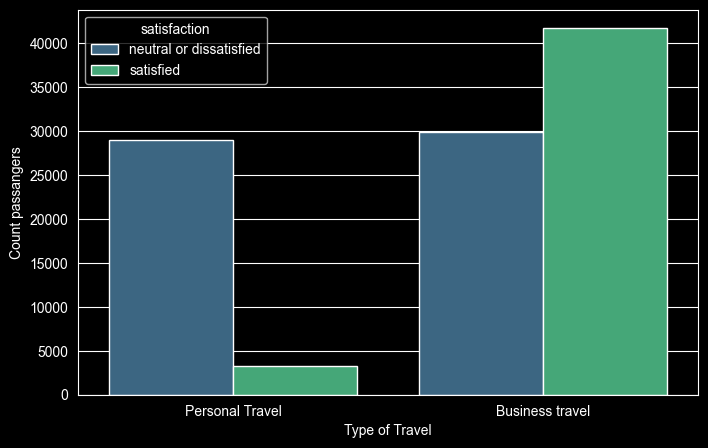

In [113]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Type of Travel',
    hue='satisfaction',
    palette='viridis'
)
plt.xlabel('Type of Travel')
plt.ylabel('Count passangers')
plt.show()

When passengers travel for personal reasons, they are mainly neutral or dissatisfied.

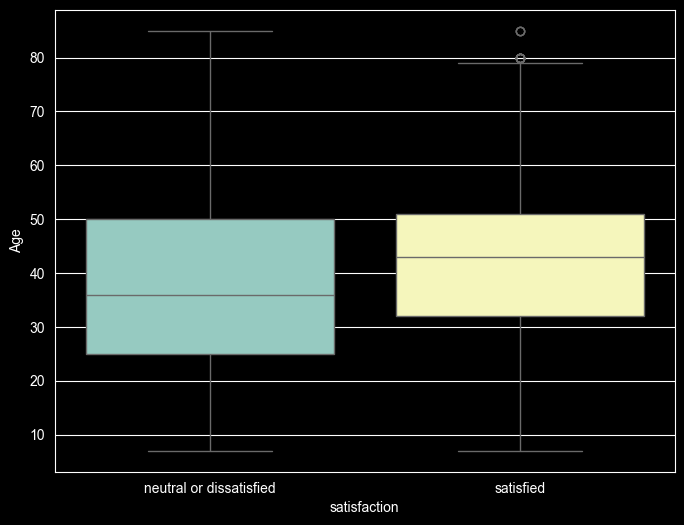

In [115]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='satisfaction', y='Age', hue='satisfaction', legend=False)
plt.show()

The median age for **satisfied** passengers is noticeably higher (around **45 years**) compared to **neutral/dissatisfied** passengers (around **35 years**). The "box" for satisfied passengers is more concentrated in the older age bracket (approx. 35–50), while the dissatisfied group has a wider spread in the younger direction.

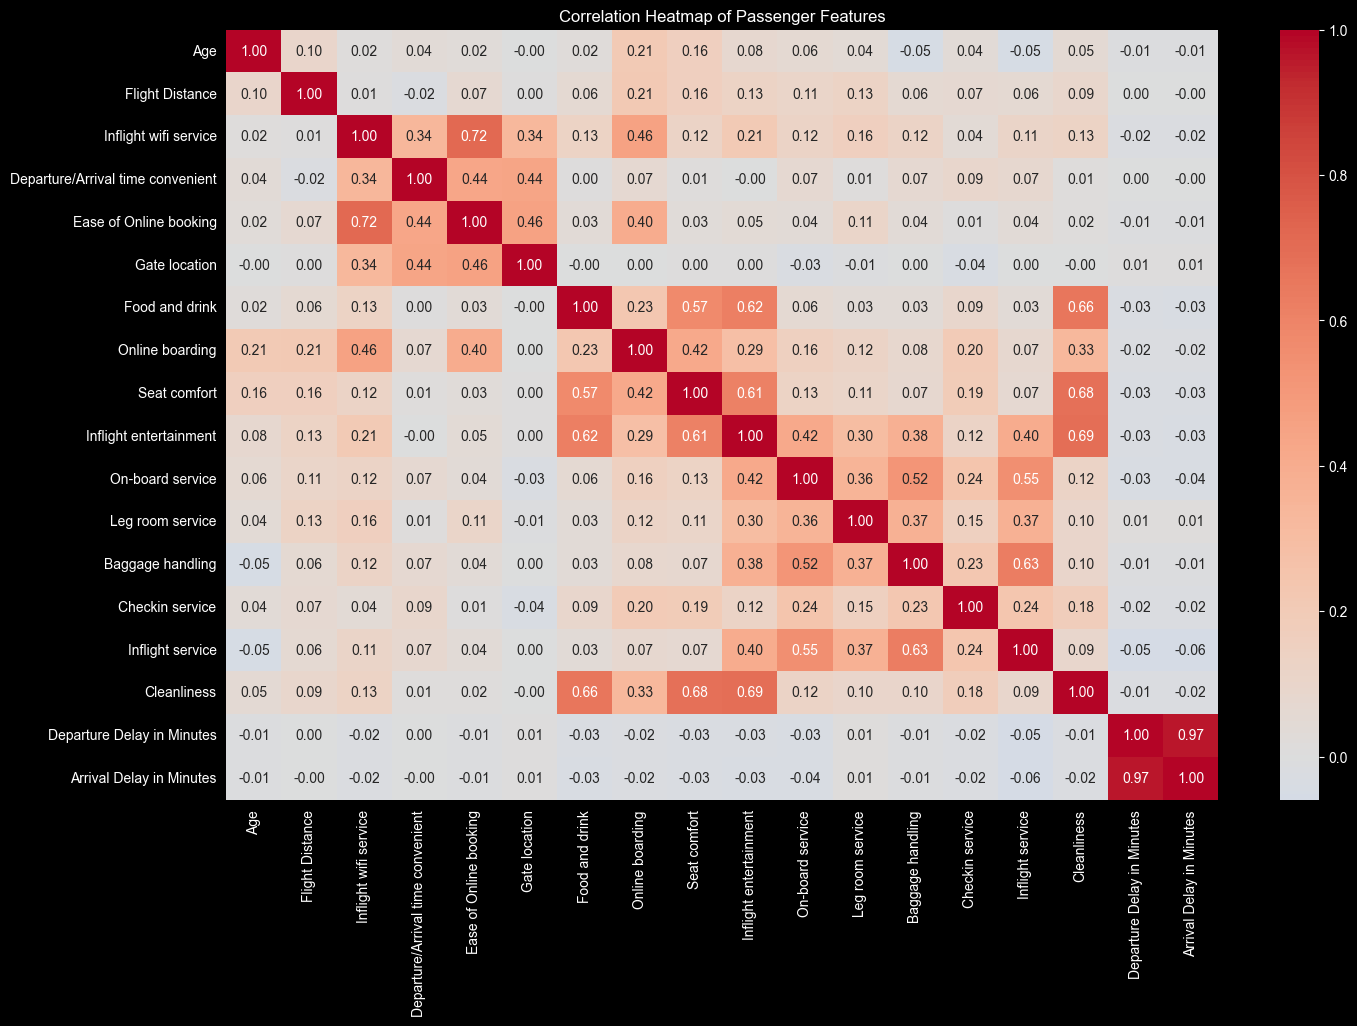

In [116]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(16, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Passenger Features')
plt.show()

Due to the extreme correlation between departure and arrival delays, we should consider dropping one of them or combining them into a single `Total_Delay` feature to simplify the model. Features like `Cleanliness`, `Food and drink`, `Seat comfort`, and `Inflight entertainment` show moderate to strong positive correlations with each other. This suggests that passengers who are happy with one aspect of the physical cabin environment tend to be happy with others.